# EDA + Premodel

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
df_coolers = pd.read_csv('/content/gdrive/MyDrive/datos_h4h/Coolers.csv')

df_clientes = pd.read_csv('/content/gdrive/MyDrive/datos_h4h/Clientes.csv')

df_train_raw = pd.read_csv('/content/gdrive/MyDrive/datos_h4h/sales_churn_train.csv')

df_test_raw = pd.read_csv('/content/gdrive/MyDrive/datos_h4h/sales_churn_test.csv')
df_test = df_test_raw.copy()

df_preds = pd.read_csv('/content/gdrive/MyDrive/datos_h4h/preds_submission.csv')


In [ ]:
df = sales_train.merge(clientes, on=['customer_id'], how='left')
df = df.merge(coolers, on=['customer_id', 'calmonth'], how='left')

In [ ]:
customer_churn_status = df.groupby('customer_id')['target'].max()

churn_counts = customer_churn_status.value_counts()
churn_pct = customer_churn_status.value_counts(normalize=True)

# 1. Bar chart (Distribución de Clientes por Churn)
plt.figure(figsize=(10, 6))
ax0 = plt.gca()
churn_counts.plot(kind='bar', ax=ax0, color=['red', 'orange'])
ax0.set_title('Distribución de Clientes por Churn', fontsize=14, fontweight='bold')
ax0.set_ylabel('Número de Clientes')
ax0.set_xticklabels(['No Churn', 'Churn'], rotation=0)
ax0.set_yscale('log')

for i, v in enumerate(churn_counts):
    ax0.text(i, v * 0.98, f'{v:,}', ha='center', va='top', color='black')

plt.tight_layout()
plt.show()

# 2. Pie chart (Proporción de Churn )
plt.figure(figsize=(8, 6))
ax1 = plt.gca()
colors = ['red', 'orange']
explode = (0.05, 0.15)
ax1.pie(churn_pct, labels=['No Churn', 'Churn'], autopct='%1.2f%%',
            colors=colors, explode=explode, startangle=90,
            textprops={'fontsize': 11}, pctdistance=0.805, labeldistance=1.05)
ax1.set_title('Proporción de Churn (%)', fontsize=14, fontweight='bold')
ax1.add_patch(plt.Circle((0, 0), 0.6, fc='white'))

plt.tight_layout()
plt.show()

print(f"\nInsight de negocio:")
print(f"\nSolo {churn_pct.get(1, 0):.2%} de los clientes churnean.")


In [ ]:
def ym_to_sequential_month(ym):
    year = ym // 100
    month = ym % 100
    return year * 12 + month

ventas_mensuales = df.groupby(['customer_id', 'calmonth'])['uni_boxes_sold_m'].sum().reset_index()

clientes_churn_ids = customer_churn_status[customer_churn_status == 1].index.unique()

churn_months = df[df['target'] == 1].groupby('customer_id')['calmonth'].min().reset_index()
churn_months.rename(columns={'calmonth': 'mes_churn'}, inplace=True)

ventas_churn = ventas_mensuales[ventas_mensuales['customer_id'].isin(clientes_churn_ids)]
ventas_churn = ventas_churn.merge(churn_months, on='customer_id')

ventas_churn['sequential_mes'] = ventas_churn['calmonth'].apply(ym_to_sequential_month)
ventas_churn['sequential_mes_churn'] = ventas_churn['mes_churn'].apply(ym_to_sequential_month)

ventas_churn['meses_antes'] = ventas_churn['sequential_mes_churn'] - ventas_churn['sequential_mes']

ventas_churn = ventas_churn[(ventas_churn['meses_antes'] >= 0) &
                            (ventas_churn['meses_antes'] <= 6)]

tendencia = ventas_churn.groupby('meses_antes')['uni_boxes_sold_m'].agg(['mean', 'median', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Tendencia de ventas
plt.sca(axes[0])
plt.plot(tendencia.index, tendencia['mean'], marker='o', linewidth=3,
         markersize=10, color='red', label='Promedio')
plt.plot(tendencia.index, tendencia['median'], marker='s', linewidth=2,
         markersize=8, color='orange', label='Mediana', linestyle='--')
plt.fill_between(tendencia.index,
                 tendencia['mean'] - tendencia['mean'].std(),
                 tendencia['mean'] + tendencia['mean'].std(),
                 alpha=0.2, color='red')

plt.title('Caída de Ventas ANTES del Churn\n(Solo clientes que churnearon)',
          fontsize=14, fontweight='bold')
plt.xlabel('Meses antes del churn', fontsize=12)
plt.ylabel('Unidades vendidas (promedio)', fontsize=12)
plt.xticks(range(7))
plt.grid(True, alpha=0.3)
plt.legend()

# Anotar la caída porcentual
# First, sort the tendency index to ensure correct iloc usage for time series analysis
tendencia = tendencia.sort_index(ascending=False) # Sort to have 6 months before at index 0 and 0 at index -1
caida = ((tendencia['mean'].iloc[-1] - tendencia['mean'].iloc[0]) /
         tendencia['mean'].iloc[0] * 100)

axes[0].text(3, tendencia['mean'].max() * 0.9,
            f'Caída: {abs(caida):.1f}%',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.8))

# Gráfico 2: Número de observaciones por mes
plt.sca(axes[1])
plt.bar(tendencia.index, tendencia['count'], color='#3498db', alpha=0.7)
plt.title('Datos disponibles por mes', fontsize=14, fontweight='bold')
plt.xlabel('Meses antes del churn')
plt.ylabel('Número de observaciones')
plt.xticks(range(7))

for i, v in enumerate(tendencia['count']):
    axes[1].text(i, v + max(tendencia['count'])*0.01, f'{v:,}',
                ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"   • Las ventas caen {abs(caida):.1f}% en los 6 meses previos")
if abs(caida) > 30:
    print(f"\nRecomendación: Actuar en el mes 3 o 4")
else:
    print(f"\nCaída moderada -> Necesitas features adicionales")

In [ ]:
# Número máximo de coolers por cliente
coolers_max = df.groupby('customer_id')['num_coolers'].max().reset_index()
coolers_max.columns = ['customer_id', 'coolers_max']

# Merge con customer_churn_status (que actúa como 'labels')
df_coolers = coolers_max.merge(
    customer_churn_status.reset_index().rename(columns={'target': 'churn'}),
    on='customer_id'
)

# Tratar clientes 'sin coolers' (NaN en coolers_max) como 0 coolers
df_coolers['coolers_max'] = df_coolers['coolers_max'].fillna(0)

# Calcular tasas de churn por número de coolers
tasa_churn_coolers = df_coolers.groupby('coolers_max').agg({
    'churn': ['mean', 'count', 'sum']
}).round(4)
tasa_churn_coolers.columns = ['tasa_churn', 'total_clientes', 'clientes_churn']
tasa_churn_coolers = tasa_churn_coolers.reset_index()

print("=" * 70)
print("ANÁLISIS: COOLERS VS CHURN")
print("=" * 70)
display(tasa_churn_coolers.style.format({
    'tasa_churn': '{:.2%}',
    'total_clientes': '{:,.0f}',
    'clientes_churn': '{:,.0f}'
}))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Crear un DataFrame filtrado para la visualización:
# Incluir siempre coolers_max = 0 (clientes sin coolers)
# Incluir otros coolers_max solo si la tasa de churn es mayor que 0 (para evitar barras irrelevantes)
tasa_churn_coolers_plot = tasa_churn_coolers[
    (tasa_churn_coolers['coolers_max'] == 0) |
    (tasa_churn_coolers['tasa_churn'] > 0)
].copy() # Usar .copy() para evitar SettingWithCopyWarning

# Gráfico 1: Tasa de churn por número de coolers
sns.barplot(data=tasa_churn_coolers_plot, x='coolers_max', y='tasa_churn', hue='coolers_max',
            ax=axes[0], palette='Reds_r', legend=False)
axes[0].set_title('Tasa de Churn vs. Número de Coolers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de coolers en punto de venta')
axes[0].set_ylabel('Tasa de Churn')
axes[0].set_ylim(0, tasa_churn_coolers_plot['tasa_churn'].max() * 1.2)

for i, row in tasa_churn_coolers_plot.iterrows():
    axes[0].text(i, row['tasa_churn'] + 0.005, f"{row['tasa_churn']:.2%}",
                ha='center', va='bottom', fontweight='bold', rotation=90)

# Gráfico 2: Distribución de clientes (usando el mismo conjunto filtrado)
sns.barplot(data=tasa_churn_coolers_plot, x='coolers_max', y='total_clientes', hue='coolers_max',
            ax=axes[1], palette='Reds_d', legend=False)
axes[1].set_title('Distribución de Clientes por # de Coolers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de coolers')
axes[1].set_ylabel('Total de clientes')

for i, row in tasa_churn_coolers_plot.iterrows():
    axes[1].text(i, row['total_clientes'] + max(tasa_churn_coolers_plot['total_clientes'])*0.01,
                f"{row['total_clientes']:,.0f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_3_coolers_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight
sin_coolers = tasa_churn_coolers[tasa_churn_coolers['coolers_max'] == 0]['tasa_churn'].values
con_coolers = tasa_churn_coolers[tasa_churn_coolers['coolers_max'] > 0]['tasa_churn'].mean()

if len(sin_coolers) > 0:
    ratio = sin_coolers[0] / con_coolers if con_coolers > 0 else 0
    print(f"   • Clientes SIN coolers: {sin_coolers[0]:.2%} churn")
    print(f"   • Clientes CON coolers: {con_coolers:.2%} churn")
else:
    print("   • No hay datos para clientes sin coolers o no se encontraron diferencias significativas.")

In [3]:

print(f"  df_train_raw : {df_train_raw.shape}")
print(f"  df_test      : {df_test.shape}")
print(f"  df_coolers   : {df_coolers.shape}")
print(f"  df_clientes  : {df_clientes.shape}")
print(f"  df_preds     : {df_preds.shape}")


  df_train_raw : (5030534, 5)
  df_test      : (199923, 4)
  df_coolers   : (4636676, 4)
  df_clientes  : (371727, 4)
  df_preds     : (199923, 2)


In [4]:
from scipy.stats import linregress

def calcular_pendiente(g):
    if len(g) < 2:
        return 0.0
    return linregress(np.arange(len(g)), g['uni_boxes_sold_m'].values)[0]

def calcular_streak(s):
    """Calcula meses consecutivos sin compra desde el mes más reciente."""
    return int((s == 0).cumprod().sum())

def build_features_v2(df_transaccional_raw, df_clientes, df_coolers, es_train=True):
    df = df_transaccional_raw.sort_values(['customer_id', 'calmonth']).copy()
    if 'target' in df.columns:
        df = df.drop(columns=['target'])

    # Para train excluimos el último mes disponible (donde vive el target real)
    if es_train:
        df = (
            df.groupby('customer_id')
              .apply(lambda g: g.iloc[:-1] if len(g) > 1 else g)
              .reset_index(drop=True)
        )

    # ── A. Histórico global ──────────────────────────────────
    agg_hist = df.groupby('customer_id').agg(
        num_meses              = ('calmonth',          'count'),
        total_cajas            = ('uni_boxes_sold_m',  'sum'),
        promedio_cajas         = ('uni_boxes_sold_m',  'mean'),
        std_cajas              = ('uni_boxes_sold_m',  'std'),
        max_cajas              = ('uni_boxes_sold_m',  'max'),
        min_cajas              = ('uni_boxes_sold_m',  'min'),
        total_transacciones    = ('num_transacciones', 'sum'),
        promedio_transacciones = ('num_transacciones', 'mean'),
        ultimo_calmonth        = ('calmonth',          'max'),
    ).reset_index()
    agg_hist['cv_cajas'] = agg_hist['std_cajas'] / (agg_hist['promedio_cajas'] + 0.1)

    # ── B. Últimos 3 meses ───────────────────────────────────
    agg_3m = (
        df.groupby('customer_id').tail(3)
          .groupby('customer_id').agg(
              promedio_cajas_3m         = ('uni_boxes_sold_m',  'mean'),
              promedio_transacciones_3m = ('num_transacciones', 'mean'),
              total_cajas_3m            = ('uni_boxes_sold_m',  'sum'),
          ).reset_index()
    )

    # ── C. Últimos 6 meses ───────────────────────────────────
    agg_6m = (
        df.groupby('customer_id').tail(6)
          .groupby('customer_id').agg(
              promedio_cajas_6m         = ('uni_boxes_sold_m',  'mean'),
              promedio_transacciones_6m = ('num_transacciones', 'mean'),
          ).reset_index()
    )

    # ── D. Pendiente lineal ──────────────────────────────────
    print("  → Calculando pendiente de ventas...")
    pendientes = (
        df.groupby('customer_id')
          .apply(calcular_pendiente)
          .reset_index()
          .rename(columns={0: 'pendiente_ventas'})
    )

    # ── E. Streak sin compra ─────────────────────────────────
    print("  → Calculando streak sin compra...")
    df['compro'] = (df['uni_boxes_sold_m'] > 0).astype(int)
    streak = (
        df.sort_values(['customer_id', 'calmonth'], ascending=[True, False])
          .groupby('customer_id')['compro']
          .apply(calcular_streak)
          .reset_index()
          .rename(columns={'compro': 'meses_sin_compra'})
    )

    # ── F. Consolidar variables transaccionales ──────────────
    feat = agg_hist.copy()
    for df_extra in [agg_3m, agg_6m, pendientes, streak]:
        feat = feat.merge(df_extra, on='customer_id', how='left')

    # Ratios e indicadores de caída
    feat['caida_3m_vs_hist'] = feat['promedio_cajas_3m'] / (feat['promedio_cajas'] + 0.1)
    feat['caida_6m_vs_hist'] = feat['promedio_cajas_6m'] / (feat['promedio_cajas'] + 0.1)
    feat['caida_3m_vs_6m']   = feat['promedio_cajas_3m'] / (feat['promedio_cajas_6m'] + 0.1)
    feat['caida_tx_3m']      = feat['promedio_transacciones_3m'] / (feat['promedio_transacciones'] + 0.1)

    # ── G. Infraestructura de Coolers ────────────────────────
    print("  → Agregando coolers...")
    coolers_last = (
        df_coolers.sort_values('calmonth')
                  .groupby('customer_id').last()
                  .reset_index()
                  [['customer_id', 'num_coolers', 'num_doors']]
    )
    coolers_tend = (
        df_coolers.sort_values(['customer_id', 'calmonth'])
                  .groupby('customer_id')
                  .apply(lambda g: linregress(np.arange(len(g)), g['num_coolers'].values)[0]
                         if len(g) >= 2 else 0.0)
                  .reset_index()
                  .rename(columns={0: 'pendiente_coolers'})
    )
    feat = feat.merge(coolers_last, on='customer_id', how='left')
    feat = feat.merge(coolers_tend, on='customer_id', how='left')
    feat['num_coolers']       = feat['num_coolers'].fillna(0)
    feat['num_doors']         = feat['num_doors'].fillna(0)
    feat['pendiente_coolers'] = feat['pendiente_coolers'].fillna(0)
    feat['sin_coolers']       = (feat['num_coolers'] == 0).astype(int)
    feat['eficiencia_cooler'] = feat['promedio_cajas'] / (feat['num_doors'] + 0.1)
    feat['cajas_por_cooler']  = feat['promedio_cajas'] / (feat['num_coolers'] + 0.1)

    # ── H. Clientes e Información Geográfica ─────────────────
    feat = feat.merge(df_clientes, on='customer_id', how='left')
    feat['rtm_customer_size_d'] = feat['rtm_customer_size_d'].fillna('Desconocido')

    return feat

In [5]:
# Preparación de la historia completa para el set de prueba
hist_para_test = pd.concat([
    df_train_raw[df_train_raw['customer_id'].isin(df_test['customer_id'])].drop(columns=['target']),
    df_test
], ignore_index=True).sort_values(['customer_id', 'calmonth'])

print("Procesando train (excluyendo último mes para evitar Data Leakage)...")
X_train_v2 = build_features_v2(df_train_raw, df_clientes, df_coolers, es_train=True)

print("\nProcesando test...")
X_test_v2  = build_features_v2(hist_para_test, df_clientes, df_coolers, es_train=False)

# Obtener target mapeado por cliente
df_y = df_train_raw.sort_values(['customer_id', 'calmonth']).groupby('customer_id').last()[['target']].reset_index()
y_v2 = X_train_v2.merge(df_y, on='customer_id', how='left')['target'].values

# Máscara para limpiar nulos de alineación de IDs
mask = ~np.isnan(y_v2)
y_v2 = y_v2[mask]

# CORRECCIÓN DE SESGO: Se añade 'num_meses' al drop antes de entrenar
X_v2      = X_train_v2[mask].drop(columns=['customer_id', 'ultimo_calmonth', 'num_meses']).copy()
X_test_v2 = X_test_v2.drop(columns=['customer_id', 'ultimo_calmonth', 'num_meses']).copy()

# Tratamiento de valores nulos estadísticos en clientes con un solo mes registrado
X_v2['std_cajas'] = X_v2['std_cajas'].fillna(0)
X_v2['cv_cajas']  = X_v2['cv_cajas'].fillna(0)
X_test_v2['std_cajas'] = X_test_v2['std_cajas'].fillna(0)
X_test_v2['cv_cajas']  = X_test_v2['cv_cajas'].fillna(0)

# Tratamiento unificado de variables categóricas
CAT_COLS = ['territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d']
for col in CAT_COLS:
    X_v2[col]      = X_v2[col].astype('category')
    X_test_v2[col] = X_test_v2[col].astype('category')

cats = {col: X_v2[col].cat.categories.union(X_test_v2[col].cat.categories) for col in CAT_COLS}
for col in CAT_COLS:
    X_v2[col]      = X_v2[col].cat.set_categories(cats[col])
    X_test_v2[col] = X_test_v2[col].cat.set_categories(cats[col])

print("\n" + "─"*50)
print(f"X_v2 (Train Final) : {X_v2.shape}")
print(f"X_test_v2 (Test Final) : {X_test_v2.shape}")
print(f"Número de Churns en Train: {y_v2.sum():,.0f} ({y_v2.mean():.2%})")

Procesando train (excluyendo último mes para evitar Data Leakage)...
  → Calculando pendiente de ventas...
  → Calculando streak sin compra...
  → Agregando coolers...

Procesando test...
  → Calculando pendiente de ventas...
  → Calculando streak sin compra...
  → Agregando coolers...

──────────────────────────────────────────────────
X_v2 (Train Final) : (241805, 28)
X_test_v2 (Test Final) : (199923, 28)
Número de Churns en Train: 43,402 (17.95%)


In [6]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

print("=" * 50)
print("ENTRENAMIENTO — LightGBM 5-Fold Stratified CV (Sin Sesgo)")
print("=" * 50)

neg = (y_v2 == 0).sum()
pos = (y_v2 == 1).sum()
ratio = neg / pos
print(f"Ratio de desbalance de clases: {ratio:.2f}x\n")

params = {
    'objective':         'binary',
    'metric':            ['auc', 'average_precision'],
    'scale_pos_weight':  ratio,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 50,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'lambda_l1':         0.1,
    'lambda_l2':         0.1,
    'verbose':           -1,
    'random_state':      42,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_v2   = np.zeros(len(X_v2))
test_v2  = np.zeros(len(X_test_v2))
modelos_v2 = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_v2, y_v2)):
    X_tr, X_val = X_v2.iloc[tr_idx], X_v2.iloc[val_idx]
    y_tr, y_val = y_v2[tr_idx],      y_v2[val_idx]

    model = lgb.LGBMClassifier(**params, n_estimators=2000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0), # Silenciar iteraciones intermedias
        ]
    )

    oof_v2[val_idx] = model.predict_proba(X_val)[:, 1]
    test_v2        += model.predict_proba(X_test_v2)[:, 1] / 5
    modelos_v2.append(model)

    auc    = roc_auc_score(y_val, oof_v2[val_idx])
    pr_auc = average_precision_score(y_val, oof_v2[val_idx])
    print(f"Fold {fold+1} -> AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f} | Árboles óptimos: {model.best_iteration_}")

print("\n" + "─" * 40)
print(f"Métrica Global OOF AUC    : {roc_auc_score(y_v2, oof_v2):.4f}")
print(f"Métrica Global OOF PR-AUC : {average_precision_score(y_v2, oof_v2):.4f}")

ENTRENAMIENTO — LightGBM 5-Fold Stratified CV (Sin Sesgo)
Ratio de desbalance de clases: 4.57x

Fold 1 -> AUC: 0.9834 | PR-AUC: 0.9351 | Árboles óptimos: 676
Fold 2 -> AUC: 0.9846 | PR-AUC: 0.9387 | Árboles óptimos: 791
Fold 3 -> AUC: 0.9843 | PR-AUC: 0.9391 | Árboles óptimos: 635
Fold 4 -> AUC: 0.9833 | PR-AUC: 0.9330 | Árboles óptimos: 580
Fold 5 -> AUC: 0.9844 | PR-AUC: 0.9378 | Árboles óptimos: 1098

────────────────────────────────────────
Métrica Global OOF AUC    : 0.9839
Métrica Global OOF PR-AUC : 0.9366


In [7]:
# porcentaje de churns
print(f"Porcentaje de Churns en Test: {test_v2.mean():.2%}")

Porcentaje de Churns en Test: 6.91%


In [8]:
# Búsqueda del umbral que maximiza F1-Score
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_v2, (oof_v2 >= t).astype(int)) for t in thresholds]
best_t     = thresholds[np.argmax(f1_scores)]
best_f1    = max(f1_scores)

print(f"Threshold de negocio óptimo : {best_t:.2f}")
print(f"F1-Score alcanzado en OOF    : {best_f1:.4f}\n")

# Estructurar la predicción emparejando con el orden original de df_preds
pred_test = pd.DataFrame({
    'customer_id': df_preds['customer_id'].values,
    'churn_score': test_v2
})

df_submission = df_preds[['customer_id']].copy()
df_submission = df_submission.merge(pred_test, on='customer_id', how='left')
df_submission['target'] = (df_submission['churn_score'] >= best_t).astype(int)

# Guardar archivo oficial para plataforma
df_submission[['customer_id', 'target']].to_csv('submission.csv', index=False)
print(f"✓ submission.csv guardado correctamente.")
print(df_submission['target'].value_counts())

Threshold de negocio óptimo : 0.72
F1-Score alcanzado en OOF    : 0.8666

✓ submission.csv guardado correctamente.
target
0    193814
1      6109
Name: count, dtype: int64


In [9]:
import shap

# ── Importancia de características globales ──────────────────
imp_v2 = pd.DataFrame({
    'feature':    X_v2.columns,
    'importance': np.mean([m.feature_importances_ for m in modelos_v2], axis=0)
}).sort_values('importance', ascending=False)
print("Top 15 features reales del nuevo modelo:")
print(imp_v2.head(15).to_string(index=False))

# ── Cálculo de SHAP values sobre clientes en riesgo ──────────
print("\nCalculando SHAP values explicativos...")
explainer = shap.TreeExplainer(modelos_v2[0])

idx_riesgo  = np.where(test_v2 >= best_t)[0]
X_riesgo    = X_test_v2.iloc[idx_riesgo].reset_index(drop=True)
shap_values = explainer.shap_values(X_riesgo)

if isinstance(shap_values, list):
    sv = shap_values[1] # Clase positiva (Churn)
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

df_shap = pd.DataFrame(sv, columns=X_v2.columns)

# Función para extraer la feature con mayor empuje hacia el riesgo
def razon_principal(shap_row, umbral=0.0):
    positivos = shap_row[shap_row > umbral].sort_values(ascending=False)
    if len(positivos) == 0:
        return 'score_general_alto'
    return positivos.index[0] # Corrected: Changed 'privados_index' to 'positivos.index[0]'

X_riesgo['razon_principal'] = df_shap.apply(razon_principal, axis=1)
X_riesgo['churn_score']     = test_v2[idx_riesgo]

# Diccionario mapeador de Causas y Acciones de Mitigación Reales
ACCIONES = {
    'pendiente_ventas':        ('Caída sostenida en ventas',            'Visita comercial urgente — revisar competencia y satisfacción'),
    'caida_3m_vs_hist':        ('Desaceleración reciente fuerte',       'Llamada proactiva — oferta de reactivación o promoción'),
    'caida_3m_vs_6m':          ('Aceleración de caída último trimestre','Alerta inmediata al ejecutivo de cuenta'),
    'caida_6m_vs_hist':        ('Declive progresivo de mediano plazo',  'Revisión de mix de productos y frecuencia de visita'),
    'caida_tx_3m':             ('Reducción de frecuencia de compra',    'Incentivar con descuento por volumen o frecuencia'),
    'meses_sin_compra':        ('Meses consecutivos sin comprar',       'Contacto inmediato — cliente posiblemente ya perdido'),
    'sin_coolers':             ('Sin infraestructura de frío activa',   'Gestión de equipos — revisar instalación o retiro de coolers'),
    'num_coolers':             ('Infraestructura reducida',             'Evaluar inversión en equipo adicional'),
    'eficiencia_cooler':       ('Baja eficiencia de coolers',           'Auditoría de uso de equipo en punto de venta'),
    'cv_cajas':                ('Alta variabilidad en compras',         'Estabilizar con contrato o acuerdo de volumen mínimo'),
    'promedio_cajas_3m':       ('Volumen bajo reciente',                'Revisión de portafolio — ampliar SKUs disponibles'),
    'promedio_transacciones_3m':('Pocas transacciones recientes',       'Aumentar frecuencia de visita del vendedor'),
    'total_cajas':             ('Bajo volumen histórico total',         'Revisar potencial del cliente y canal'),
}

def segmentar(row):
    razon = row['razon_principal']
    score = row['churn_score']
    nivel = 'Crítico' if score >= 0.90 else ('Alto' if score >= 0.80 else 'Medio')
    causa, accion = ACCIONES.get(razon, ('Comportamiento general de riesgo', 'Revisión integral del cliente'))
    return pd.Series({'nivel_riesgo': nivel, 'causa_principal': causa, 'accion_recomendada': accion})

segmentos = X_riesgo[['churn_score', 'razon_principal']].apply(segmentar, axis=1)
X_riesgo  = pd.concat([X_riesgo[['churn_score', 'razon_principal']], segmentos], axis=1)

# Recuperación de IDs geográficos y de negocio para el reporte final
ids_riesgo = df_preds['customer_id'].values[idx_riesgo]
X_riesgo.insert(0, 'customer_id', ids_riesgo)

reporte = (
    X_riesgo
    .merge(df_clientes, on='customer_id', how='left')
    .merge(
        df_coolers.sort_values('calmonth').groupby('customer_id').last().reset_index()[['customer_id', 'num_coolers', 'num_doors']],
        on='customer_id', how='left'
    )
    .sort_values('churn_score', ascending=False)
    [['customer_id', 'churn_score', 'nivel_riesgo', 'causa_principal',
      'accion_recomendada', 'territory_d', 'comercial_subchannel_d',
      'rtm_customer_size_d', 'num_coolers', 'num_doors']]
)

Top 15 features reales del nuevo modelo:
               feature  importance
   total_transacciones      3494.4
           total_cajas      3392.8
           territory_d      3304.4
      pendiente_ventas      3006.6
             min_cajas      2756.8
promedio_transacciones      2729.4
              cv_cajas      2462.0
           caida_tx_3m      2412.0
        caida_3m_vs_6m      2129.4
        promedio_cajas      2102.4
      caida_6m_vs_hist      1958.2
     eficiencia_cooler      1754.4
      caida_3m_vs_hist      1749.0
             std_cajas      1674.6
      cajas_por_cooler      1589.0

Calculando SHAP values explicativos...


In [10]:
print("\n" + "=" * 55)
print("RESUMEN EJECUTIVO (CORREGIDO Y SIN SESGO)")
print("=" * 55)

print(f"\nClientes totales en riesgo de Churn: {len(reporte):,}")

print("\nDistribución por nivel de riesgo:")
print(reporte['nivel_riesgo'].value_counts().to_string())

print("\nTop Causas Principales de Churn Reales (Verificadas por SHAP):")
print(reporte['causa_principal'].value_counts().head(5).to_string())

print("\nDistribución por territorio (Top 10):")
print(reporte.groupby('territory_d')['customer_id'].count().sort_values(ascending=False).head(10).to_string())

print("\nDistribución por subcanal:")
print(reporte.groupby('comercial_subchannel_d')['customer_id'].count().sort_values(ascending=False).head(10).to_string())

print("\nEjemplo de Clientes Críticos Reales con Acciones Estratégicas:")
cols_show = ['customer_id', 'churn_score', 'nivel_riesgo', 'causa_principal', 'accion_recomendada']
print(reporte[reporte['nivel_riesgo'] == 'Crítico'][cols_show].head(5).to_string(index=False))

# Guardar base comercial actionable
reporte.to_csv('reporte_comercial.csv', index=False)
print(f"\n✓ reporte_comercial.csv guardado con éxito ({len(reporte):,} clientes).")


RESUMEN EJECUTIVO (CORREGIDO Y SIN SESGO)

Clientes totales en riesgo de Churn: 6,109

Distribución por nivel de riesgo:
nivel_riesgo
Crítico    2574
Alto       2119
Medio      1416

Top Causas Principales de Churn Reales (Verificadas por SHAP):
causa_principal
Comportamiento general de riesgo     5471
Reducción de frecuencia de compra     394
Bajo volumen histórico total          145
Caída sostenida en ventas              99

Distribución por territorio (Top 10):
territory_d
Guadalajara         737
Monterrey           610
Jalisco             565
Aguascalientes      387
Zacatecas           363
San Luis Potosi     346
Culiacan            287
Comarca Lagunera    276
Durango             258
Juarez              232

Distribución por subcanal:
comercial_subchannel_d
Abarrotes y bodegas               1631
Hogares                           1600
Kiosco                            1384
Licorería                          592
Verdulería                         204
Farmacia                        

# regresion logistica

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Preparando matrices específicas para Regresión Logística...")

# 1. Identificar columnas numéricas y categóricas
num_cols = X_v2.select_dtypes(exclude=['category']).columns.tolist()
cat_cols = X_v2.select_dtypes(include=['category']).columns.tolist()

# 2. Copias de las matrices base
X_lr = X_v2.copy()
X_test_lr = X_test_v2.copy()

# 3. Escalar las variables numéricas
scaler = StandardScaler()
X_lr[num_cols] = scaler.fit_transform(X_lr[num_cols])
X_test_lr[num_cols] = scaler.transform(X_test_lr[num_cols])

# 4. Aplicar One-Hot Encoding a las categóricas
X_lr = pd.get_dummies(X_lr, columns=cat_cols, drop_first=True)
X_test_lr = pd.get_dummies(X_test_lr, columns=cat_cols, drop_first=True)

# Asegurar que ambos sets tengan exactamente las mismas columnas tras el One-Hot
X_lr, X_test_lr = X_lr.align(X_test_lr, join='left', axis=1, fill_value=0)

# Para Random Forest podemos usar Label Encoding rápido o rellenar dummies
X_rf = X_lr.copy()
X_test_rf = X_test_lr.copy()

print(f"✓ Matrices listas. Dimensiones para LR/RF: {X_lr.shape}")

Preparando matrices específicas para Regresión Logística...
✓ Matrices listas. Dimensiones para LR/RF: (241805, 65)


random y reg log

In [12]:
print("=" * 50)
print("ENTRENANDO BASELINE: REGRESIÓN LOGÍSTICA")
print("=" * 50)

oof_lr = np.zeros(len(X_lr))
test_lr = np.zeros(len(X_test_lr))

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_lr, y_v2)):
    X_tr, X_val = X_lr.iloc[tr_idx], X_lr.iloc[val_idx]
    y_tr, y_val = y_v2[tr_idx], y_v2[val_idx]

    # Usamos class_weight='balanced' para compensar el desbalance de la señal
    model_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    model_lr.fit(X_tr, y_tr)

    oof_lr[val_idx] = model_lr.predict_proba(X_val)[:, 1]
    test_lr += model_lr.predict_proba(X_test_lr)[:, 1] / 5

auc_lr = roc_auc_score(y_v2, oof_lr)
pr_auc_lr = average_precision_score(y_v2, oof_lr)
print(f">> Baseline LR OOF AUC: {auc_lr:.4f} | PR-AUC: {pr_auc_lr:.4f}\n")


print("=" * 50)
print("ENTRENANDO COMPETIDOR: RANDOM FOREST")
print("=" * 50)

oof_rf = np.zeros(len(X_rf))
test_rf = np.zeros(len(X_test_rf))

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_rf, y_v2)):
    X_tr, X_val = X_rf.iloc[tr_idx], X_rf.iloc[val_idx]
    y_tr, y_val = y_v2[tr_idx], y_v2[val_idx]

    # Ajustamos hiperparámetros base de RF para agilizar cómputo y controlar sobreajuste
    model_rf = RandomForestClassifier(n_estimators=150, max_depth=12, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
    model_rf.fit(X_tr, y_tr)

    oof_rf[val_idx] = model_rf.predict_proba(X_val)[:, 1]
    test_rf += model_rf.predict_proba(X_test_rf)[:, 1] / 5

auc_rf = roc_auc_score(y_v2, oof_rf)
pr_auc_rf = average_precision_score(y_v2, oof_rf)
print(f">> Competidor RF OOF AUC: {auc_rf:.4f} | PR-AUC: {pr_auc_rf:.4f}")

ENTRENANDO BASELINE: REGRESIÓN LOGÍSTICA
>> Baseline LR OOF AUC: 0.9598 | PR-AUC: 0.8348

ENTRENANDO COMPETIDOR: RANDOM FOREST
>> Competidor RF OOF AUC: 0.9715 | PR-AUC: 0.8909


In [13]:
# porcentaje de churns
print(f"Porcentaje de Churns en Test (LR): {test_lr.mean():.2%}")
print(f"Porcentaje de Churns en Test (RF): {test_rf.mean():.2%}")


Porcentaje de Churns en Test (LR): 15.97%
Porcentaje de Churns en Test (RF): 14.47%


In [14]:
# 1. Recuperar métricas del LightGBM entrenado en la Celda 3
auc_lgb = roc_auc_score(y_v2, oof_v2)
pr_auc_lgb = average_precision_score(y_v2, oof_v2)

# Calcular F1 máximo para cada uno usando optimización de umbrales
def get_best_f1(y_true, oof_preds):
    ts = np.arange(0.1, 0.9, 0.01)
    scores = [f1_score(y_true, (oof_preds >= t).astype(int)) for t in ts]
    return max(scores)

f1_lr = get_best_f1(y_v2, oof_lr)
f1_rf = get_best_f1(y_v2, oof_rf)
f1_lgb = get_best_f1(y_v2, oof_v2)

# 2. Construir la tabla comparativa
df_metricas = pd.DataFrame({
    'Modelo': ['Regresión Logística (Baseline)', 'Random Forest (Competidor)', 'LightGBM (Modelo Propuesto)'],
    'OOF AUC-ROC (Discriminación)': [auc_lr, auc_rf, auc_lgb],
    'OOF PR-AUC (Precisión Promedio)': [pr_auc_lr, pr_auc_rf, pr_auc_lgb],
    'Max F1-Score (Balance Negocio)': [f1_lr, f1_rf, f1_lgb]
})

print("=" * 65)
print("TABLA COMPARATIVA DE RENDIMIENTO (VALIDACIÓN CRUZADA OOF)")
print("=" * 65)
print(df_metricas.to_string(index=False))
print("=" * 65)

# Guardar tabla como soporte de experimentación
df_metricas.to_csv('cuadro_comparativo_modelos.csv', index=False)
print("✓ Archivo 'cuadro_comparativo_modelos.csv' guardado.")

TABLA COMPARATIVA DE RENDIMIENTO (VALIDACIÓN CRUZADA OOF)
                        Modelo  OOF AUC-ROC (Discriminación)  OOF PR-AUC (Precisión Promedio)  Max F1-Score (Balance Negocio)
Regresión Logística (Baseline)                      0.959819                         0.834830                        0.783126
    Random Forest (Competidor)                      0.971512                         0.890943                        0.822328
   LightGBM (Modelo Propuesto)                      0.983929                         0.936566                        0.866557
✓ Archivo 'cuadro_comparativo_modelos.csv' guardado.


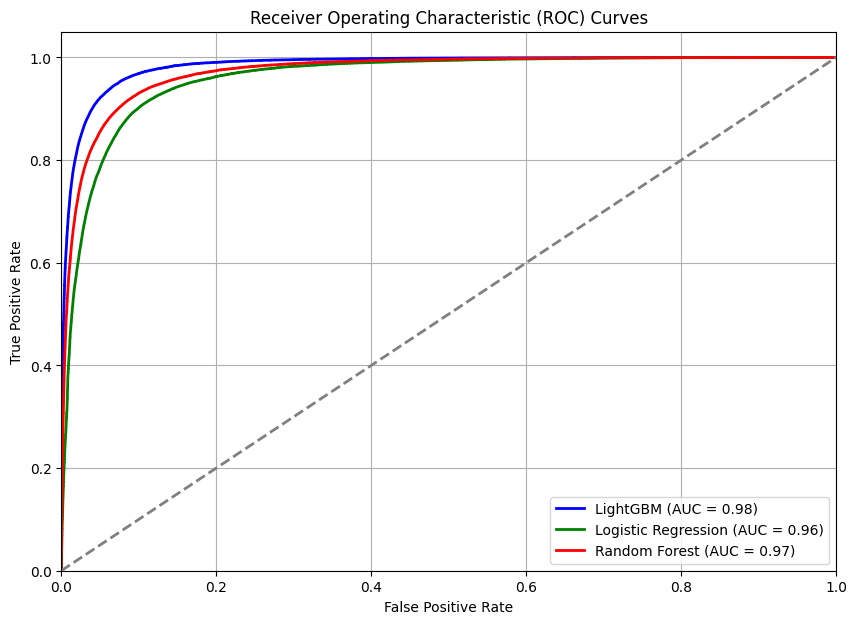

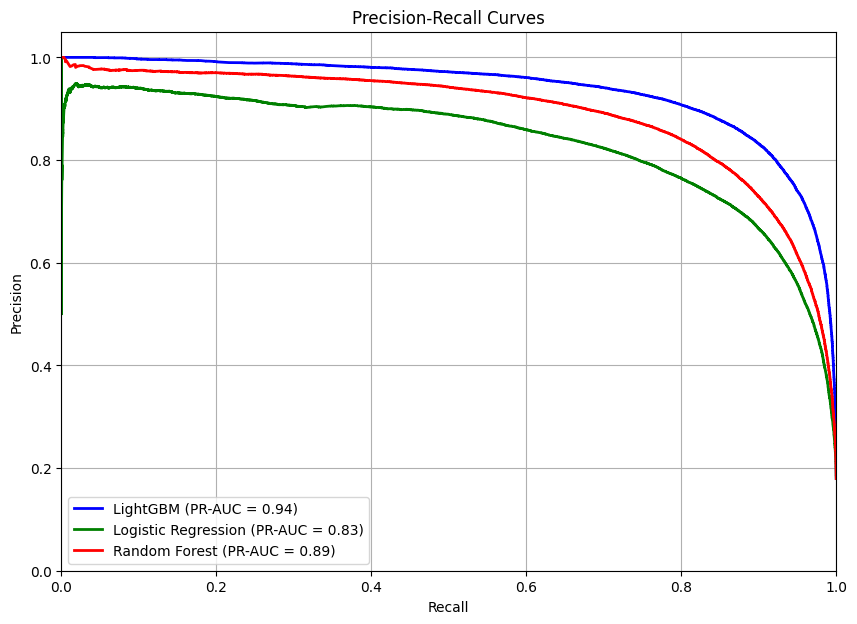

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

# --- Plotting ROC Curves ---
plt.figure(figsize=(10, 7))

# LightGBM ROC
fpr_lgb, tpr_lgb, _ = roc_curve(y_v2, oof_v2)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)
plt.plot(fpr_lgb, tpr_lgb, color='blue', lw=2, label=f'LightGBM (AUC = {roc_auc_lgb:.2f})')

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_v2, oof_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_v2, oof_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- Plotting Precision-Recall Curves ---
plt.figure(figsize=(10, 7))

# LightGBM PR
precision_lgb, recall_lgb, _ = precision_recall_curve(y_v2, oof_v2)
pr_auc_lgb = auc(recall_lgb, precision_lgb)
plt.plot(recall_lgb, precision_lgb, color='blue', lw=2, label=f'LightGBM (PR-AUC = {pr_auc_lgb:.2f})')

# Logistic Regression PR
precision_lr, recall_lr, _ = precision_recall_curve(y_v2, oof_lr)
pr_auc_lr = auc(recall_lr, precision_lr)
plt.plot(recall_lr, precision_lr, color='green', lw=2, label=f'Logistic Regression (PR-AUC = {pr_auc_lr:.2f})')

# Random Forest PR
precision_rf, recall_rf, _ = precision_recall_curve(y_v2, oof_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
plt.plot(recall_rf, precision_rf, color='red', lw=2, label=f'Random Forest (PR-AUC = {pr_auc_rf:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


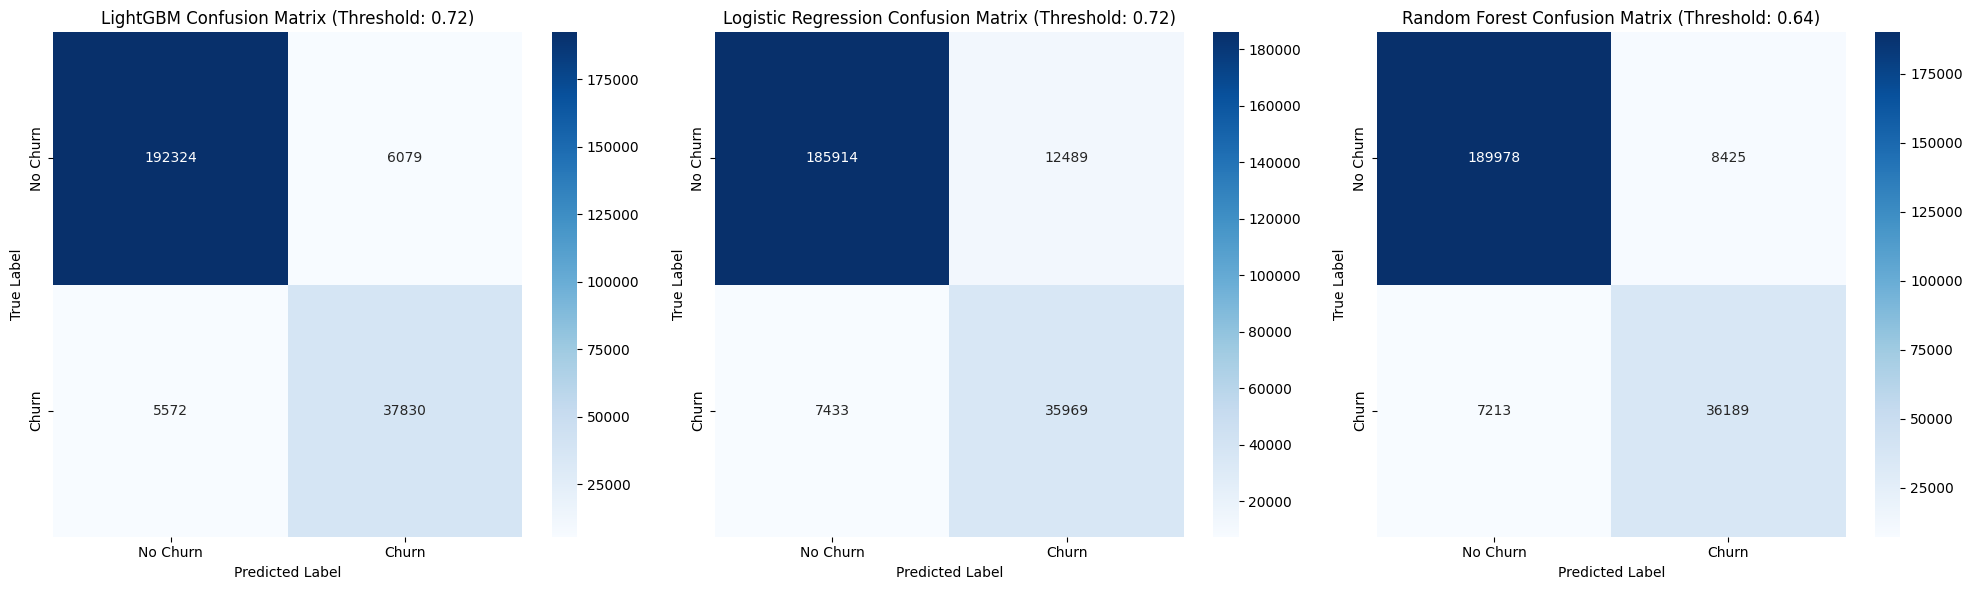

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred_proba, title, ax):
    # Find best F1 threshold for this model
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores  = [f1_score(y_true, (y_pred_proba >= t).astype(int)) for t in thresholds]
    best_t_model = thresholds[np.argmax(f1_scores)]

    y_pred = (y_pred_proba >= best_t_model).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{title} (Threshold: {best_t_model:.2f})')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_yticklabels(['No Churn', 'Churn'])


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LightGBM Confusion Matrix
plot_confusion_matrix(y_v2, oof_v2, 'LightGBM Confusion Matrix', axes[0])

# Logistic Regression Confusion Matrix
plot_confusion_matrix(y_v2, oof_lr, 'Logistic Regression Confusion Matrix', axes[1])

# Random Forest Confusion Matrix
plot_confusion_matrix(y_v2, oof_rf, 'Random Forest Confusion Matrix', axes[2])

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import recall_score

y_pred_lgb = (oof_v2 >= best_t).astype(int)
recall_lgb = recall_score(y_v2, y_pred_lgb)

print(f"Recall del Modelo LightGBM: {recall_lgb:.4f}")

Recall del Modelo LightGBM: 0.8716


### Feature Importance for Logistic Regression

In [18]:
# Get feature importance for Logistic Regression (absolute coefficients)
# We'll use the last trained LR model (model_lr) from the cross-validation loop
# Note: This is an approximation as coefficients can be negative and directly reflect direction.
# Taking absolute values gives magnitude of influence.

lr_feature_importance = pd.DataFrame({
    'feature': X_lr.columns,
    'importance': np.abs(model_lr.coef_[0])
}).sort_values('importance', ascending=False)

print("Top 15 features for Logistic Regression:")
print(lr_feature_importance.head(15).to_string(index=False))

Top 15 features for Logistic Regression:
                                              feature  importance
                            promedio_transacciones_3m    8.964294
                               promedio_transacciones    8.315451
                                  total_transacciones    6.839243
                                       promedio_cajas    5.354432
                                          total_cajas    4.844289
                                            min_cajas    4.323570
                            promedio_transacciones_6m    2.798855
                          rtm_customer_size_d_Pequeño    2.149724
                          rtm_customer_size_d_Mediano    1.751193
                      comercial_subchannel_d_Farmacia    1.700316
                                     pendiente_ventas    1.515785
                                            std_cajas    1.455829
comercial_subchannel_d_Tiendas de carne/pollo/pescado    1.451548
                     comercial_subc

### Feature Importance for Random Forest

In [19]:
# Get feature importance for Random Forest
# We'll use the last trained RF model (model_rf) from the cross-validation loop

rf_feature_importance = pd.DataFrame({
    'feature': X_rf.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features for Random Forest:")
print(rf_feature_importance.head(15).to_string(index=False))

Top 15 features for Random Forest:
                  feature  importance
              total_cajas    0.144096
      total_transacciones    0.143208
                min_cajas    0.088956
           total_cajas_3m    0.063841
promedio_transacciones_3m    0.059734
 rtm_customer_size_d_Mini    0.052940
         pendiente_ventas    0.052857
        promedio_cajas_3m    0.043380
              caida_tx_3m    0.043217
   promedio_transacciones    0.033310
           promedio_cajas    0.031569
promedio_transacciones_6m    0.030923
           caida_3m_vs_6m    0.029661
        promedio_cajas_6m    0.025442
                 cv_cajas    0.024571


### Visualizing Feature Importances

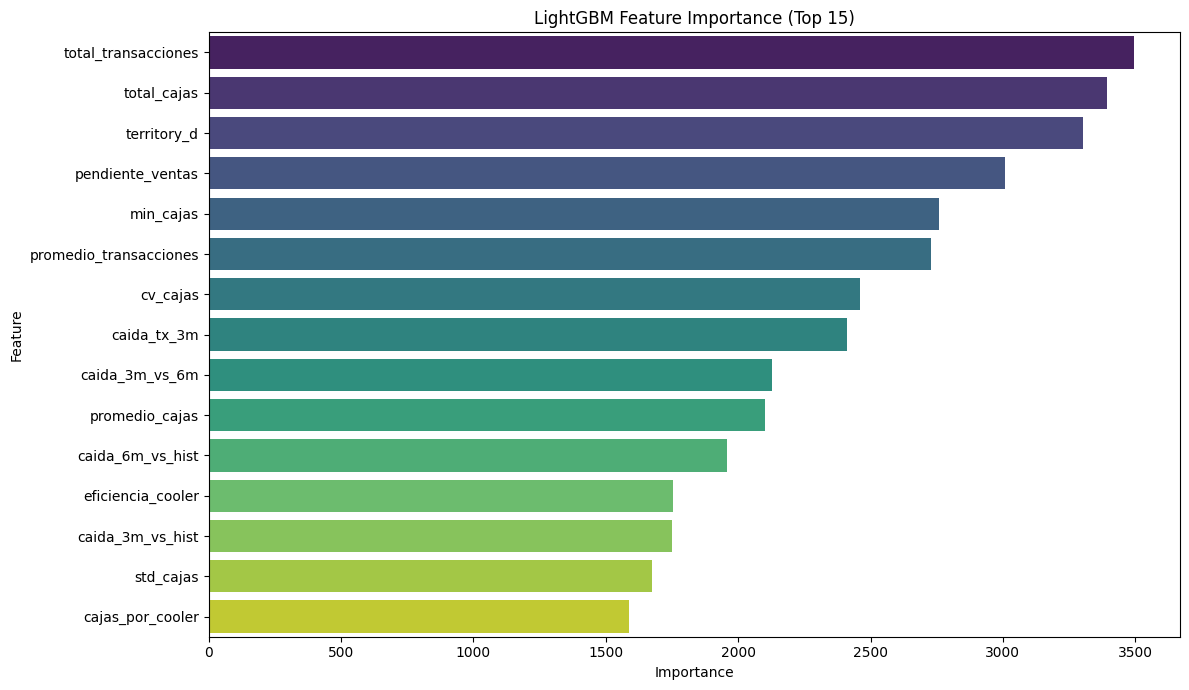

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=imp_v2.head(15), palette='viridis')
plt.title('LightGBM Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

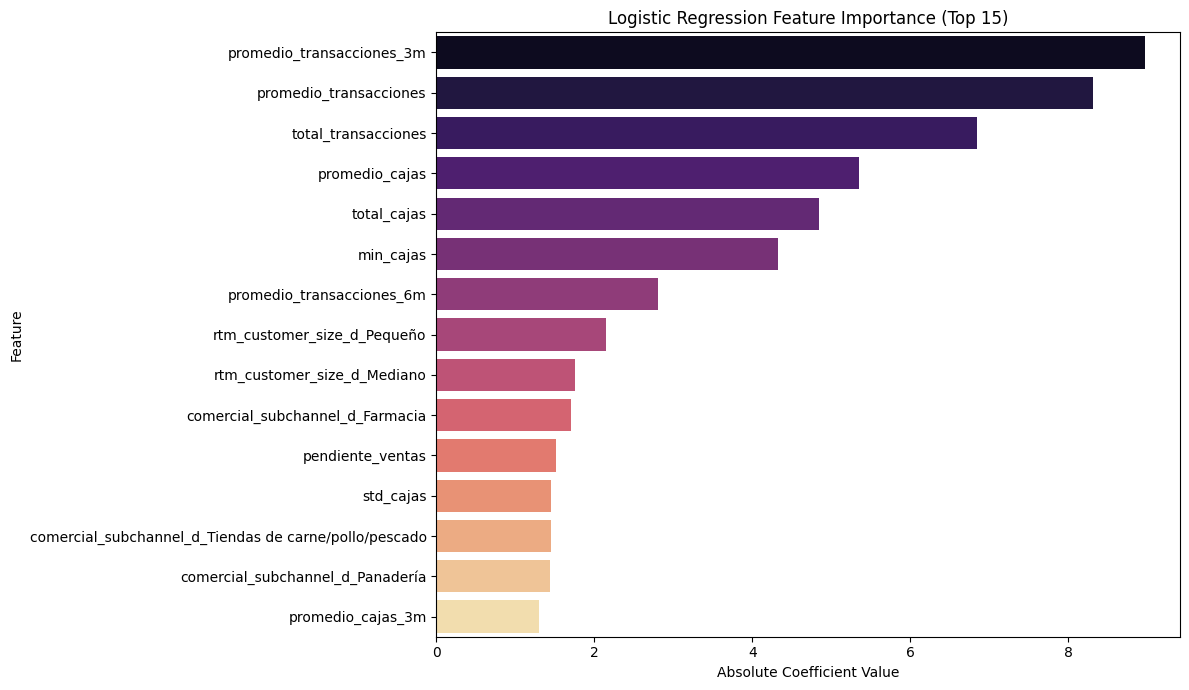

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=lr_feature_importance.head(15), palette='magma')
plt.title('Logistic Regression Feature Importance (Top 15)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

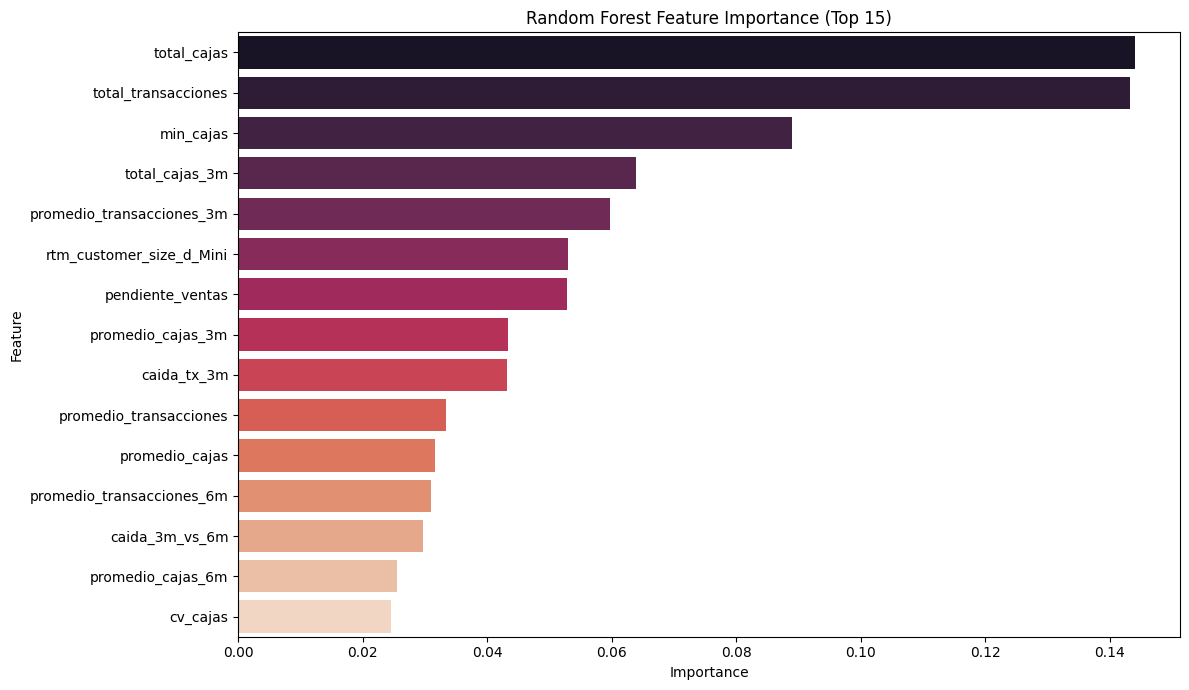

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=rf_feature_importance.head(15), palette='rocket')
plt.title('Random Forest Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [23]:
print("=" * 50)
print("ENSEMBLE: Promedio Simple de Predicciones")
print("=" * 50)

# Promedio de las predicciones OOF (Out-Of-Fold) para el set de entrenamiento
oof_ensemble = (oof_v2 + oof_lr + oof_rf) / 3

# Promedio de las predicciones del set de prueba
test_ensemble = (test_v2 + test_lr + test_rf) / 3

# Calcular métricas para el ensemble en OOF
auc_ensemble = roc_auc_score(y_v2, oof_ensemble)
pr_auc_ensemble = average_precision_score(y_v2, oof_ensemble)
f1_ensemble = get_best_f1(y_v2, oof_ensemble) # Usar la función get_best_f1 definida antes

print(f">> Ensemble OOF AUC: {auc_ensemble:.4f} | PR-AUC: {pr_auc_ensemble:.4f} | Max F1-Score: {f1_ensemble:.4f}")

# Añadir el ensemble a la tabla comparativa
df_metricas_ensemble = df_metricas.copy()
df_metricas_ensemble.loc[len(df_metricas_ensemble)] = {
    'Modelo': 'Ensemble (Promedio Simple)',
    'OOF AUC-ROC (Discriminación)': auc_ensemble,
    'OOF PR-AUC (Precisión Promedio)': pr_auc_ensemble,
    'Max F1-Score (Balance Negocio)': f1_ensemble
}

print("\n" + "=" * 65)
print("TABLA COMPARATIVA DE RENDIMIENTO (CON ENSEMBLE)")
print("=" * 65)
print(df_metricas_ensemble.to_string(index=False))
print("=" * 65)

# Determinar el umbral óptimo para el ensemble
thresholds_ensemble = np.arange(0.05, 0.95, 0.01)
f1_scores_ensemble  = [f1_score(y_v2, (oof_ensemble >= t).astype(int)) for t in thresholds_ensemble]
best_t_ensemble     = thresholds_ensemble[np.argmax(f1_scores_ensemble)]
best_f1_ensemble    = max(f1_scores_ensemble)

print(f"\nThreshold de negocio óptimo para el Ensemble : {best_t_ensemble:.2f}")
print(f"F1-Score alcanzado en OOF para el Ensemble    : {best_f1_ensemble:.4f}")

# Crear archivo de submission con el ensemble
pred_test_ensemble = pd.DataFrame({
    'customer_id': df_preds['customer_id'].values,
    'churn_score': test_ensemble
})

df_submission_ensemble = df_preds[['customer_id']].copy()
df_submission_ensemble = df_submission_ensemble.merge(pred_test_ensemble, on='customer_id', how='left')
df_submission_ensemble['target'] = (df_submission_ensemble['churn_score'] >= best_t_ensemble).astype(int)

df_submission_ensemble[['customer_id', 'target']].to_csv('submission_ensemble.csv', index=False)
print(f"\n✓ submission_ensemble.csv guardado correctamente.")
print(df_submission_ensemble['target'].value_counts())

ENSEMBLE: Promedio Simple de Predicciones
>> Ensemble OOF AUC: 0.9784 | PR-AUC: 0.9171 | Max F1-Score: 0.8502

TABLA COMPARATIVA DE RENDIMIENTO (CON ENSEMBLE)
                        Modelo  OOF AUC-ROC (Discriminación)  OOF PR-AUC (Precisión Promedio)  Max F1-Score (Balance Negocio)
Regresión Logística (Baseline)                      0.959819                         0.834830                        0.783126
    Random Forest (Competidor)                      0.971512                         0.890943                        0.822328
   LightGBM (Modelo Propuesto)                      0.983929                         0.936566                        0.866557
    Ensemble (Promedio Simple)                      0.978375                         0.917062                        0.850185

Threshold de negocio óptimo para el Ensemble : 0.68
F1-Score alcanzado en OOF para el Ensemble    : 0.8502

✓ submission_ensemble.csv guardado correctamente.
target
0    192536
1      7387
Name: count, dtype: i

In [24]:
from sklearn.metrics import roc_auc_score
import pandas as pd

print("="*60)
print("AUDITORÍA DE VARIABLES INDIVIDUALES")
print("="*60)

resultados = []

for col in X_v2.select_dtypes(exclude='category').columns:

    try:
        auc = roc_auc_score(y_v2, X_v2[col])

        if auc < 0.5:
            auc = 1 - auc

        resultados.append((col, auc))

    except:
        pass

audit = (
    pd.DataFrame(resultados, columns=['variable', 'auc'])
      .sort_values('auc', ascending=False)
)

print(audit.head(20).to_string(index=False))

AUDITORÍA DE VARIABLES INDIVIDUALES
                 variable      auc
      total_transacciones 0.896489
              total_cajas 0.893881
promedio_transacciones_3m 0.882025
           total_cajas_3m 0.881680
                min_cajas 0.881566
        promedio_cajas_3m 0.879550
promedio_transacciones_6m 0.858738
        promedio_cajas_6m 0.858537
           promedio_cajas 0.841568
   promedio_transacciones 0.839478
                max_cajas 0.831209
                std_cajas 0.739403
                num_doors 0.733370
              num_coolers 0.708477
              caida_tx_3m 0.703482
                 cv_cajas 0.702187
         cajas_por_cooler 0.697149
         pendiente_ventas 0.679909
         caida_3m_vs_hist 0.665102
        eficiencia_cooler 0.662569


In [25]:
print("="*60)
print("TOP VARIABLES LIGHTGBM")
print("="*60)

imp_pct = imp_v2.copy()
imp_pct['pct_importance'] = (
    imp_pct['importance'] /
    imp_pct['importance'].sum()
)

print(
    imp_pct[['feature','pct_importance']]
    .head(15)
    .to_string(index=False)
)

TOP VARIABLES LIGHTGBM
               feature  pct_importance
   total_transacciones        0.074552
           total_cajas        0.072384
           territory_d        0.070498
      pendiente_ventas        0.064145
             min_cajas        0.058815
promedio_transacciones        0.058231
              cv_cajas        0.052526
           caida_tx_3m        0.051459
        caida_3m_vs_6m        0.045430
        promedio_cajas        0.044854
      caida_6m_vs_hist        0.041778
     eficiencia_cooler        0.037430
      caida_3m_vs_hist        0.037314
             std_cajas        0.035727
      cajas_por_cooler        0.033901


In [26]:
print("="*60)
print("ANÁLISIS TEMPORAL")
print("="*60)

tmp = X_train_v2.copy()
tmp['target'] = y_v2

print(
    tmp.groupby('ultimo_calmonth')['target']
       .mean()
       .sort_index()
)

ANÁLISIS TEMPORAL
ultimo_calmonth
202401    1.000000
202402    1.000000
202403    1.000000
202404    1.000000
202405    1.000000
202406    1.000000
202407    1.000000
202408    1.000000
202409    1.000000
202410    1.000000
202411    1.000000
202412    1.000000
202501    1.000000
202502    1.000000
202503    1.000000
202504    1.000000
202505    1.000000
202506    1.000000
202507    1.000000
202508    1.000000
202509    1.000000
202510    1.000000
202511    1.000000
202512    0.009198
202601    0.000000
Name: target, dtype: float64


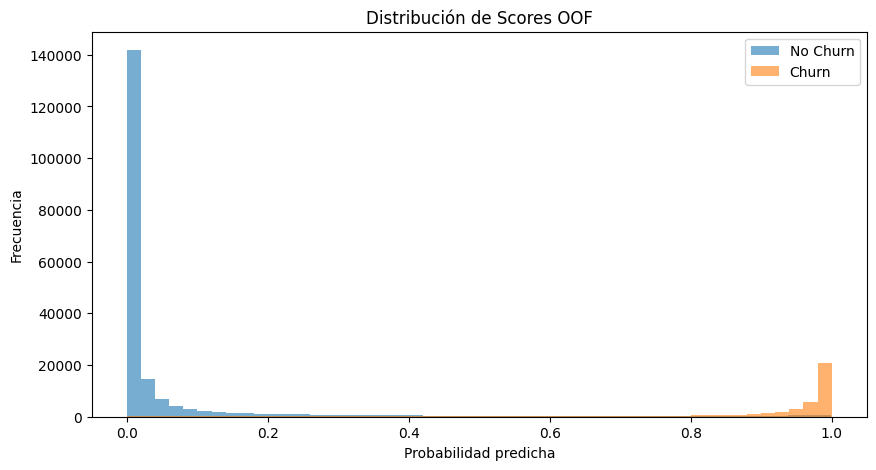

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    oof_v2[y_v2==0],
    bins=50,
    alpha=0.6,
    label='No Churn'
)

plt.hist(
    oof_v2[y_v2==1],
    bins=50,
    alpha=0.6,
    label='Churn'
)

plt.legend()
plt.title("Distribución de Scores OOF")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")

plt.show()

In [28]:
lift_df = pd.DataFrame({
    'target': y_v2,
    'score': oof_v2
})

lift_df = lift_df.sort_values(
    'score',
    ascending=False
)

lift_df['decil'] = pd.qcut(
    np.arange(len(lift_df)),
    10,
    labels=False
)

tabla_lift = (
    lift_df
    .groupby('decil')
    .agg(
        clientes=('target','count'),
        churns=('target','sum')
    )
)

tabla_lift['tasa_churn'] = (
    tabla_lift['churns'] /
    tabla_lift['clientes']
)

baseline = y_v2.mean()

tabla_lift['lift'] = (
    tabla_lift['tasa_churn'] /
    baseline
)

print(tabla_lift)

       clientes  churns  tasa_churn      lift
decil                                        
0         24181   23408    0.968033  5.393188
1         24180   16122    0.666749  3.714652
2         24181    3186    0.131756  0.734052
3         24180     454    0.018776  0.104606
4         24181     130    0.005376  0.029952
5         24180      52    0.002151  0.011981
6         24180      20    0.000827  0.004608
7         24181      17    0.000703  0.003917
8         24180      10    0.000414  0.002304
9         24181       3    0.000124  0.000691


In [29]:
top10 = int(len(lift_df)*0.10)

capturados = (
    lift_df.head(top10)['target']
    .sum()
)

total_churns = lift_df['target'].sum()

print("="*60)
print("EFECTIVIDAD OPERATIVA")
print("="*60)

print(
    f"Top 10% de clientes captura "
    f"{capturados/total_churns:.2%} "
    f"de todos los churns."
)

EFECTIVIDAD OPERATIVA
Top 10% de clientes captura 53.93% de todos los churns.


In [30]:
for pct in [0.05, 0.10, 0.20]:

    top_n = int(len(lift_df) * pct)

    capturados = (
        lift_df.head(top_n)['target']
        .sum()
    )

    total = lift_df['target'].sum()

    print(
        f"Top {pct:.0%}: "
        f"{capturados/total:.2%} de churns capturados"
    )

Top 5%: 27.54% de churns capturados
Top 10%: 53.93% de churns capturados
Top 20%: 91.08% de churns capturados
